In [ ]:
pip install Boruta

In [ ]:
import json
import numpy as np
import pandas as pd
from itertools import cycle
from boruta import BorutaPy

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, roc_curve, auc, f1_score, confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, train_test_split
from sklearn.utils import class_weight

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize

In [ ]:
expr = pd.read_table('gene_expression.txt', sep=' ')
expr_degs = pd.read_table('degs.txt', sep=' ')
labels = pd.read_csv('labels.csv', index_col=0)
common_genes = pd.read_table('common_genes.txt', names=['gene_name'], header=None)

In [ ]:
expr = expr.T
expr.columns = expr.columns.to_list()
common_genes.columns = ['gene_name']
labels.columns = ['Class']

In [ ]:
expr.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-FV-A3I0-01A-11R-A22L-07,16693,0,1419,543,132,188,644,2052,1530,2033,...,0,0,29,0,0,0,298,0,5,9
TCGA-DD-A3A6-11A-11R-A22L-07,2980,0,405,130,26,24,23606,1170,2942,165,...,0,0,2,0,0,0,163,0,0,0
TCGA-DD-A3A6-01A-11R-A22L-07,783,74,279,202,26,412,1848,2042,896,405,...,0,0,5,0,0,0,145,0,1,64
TCGA-BD-A3ER-01A-11R-A213-07,3056,0,633,397,98,237,112525,2311,3174,585,...,0,1,10,0,0,0,282,0,6,9
TCGA-CC-5261-01A-01R-A131-07,4785,0,1908,975,451,326,28847,2277,1450,2866,...,0,0,8,0,0,0,388,0,7,4


In [ ]:
expr.shape

(421, 60660)

In [ ]:
expr.columns[:15]

Index(['ENSG00000000003.15', 'ENSG00000000005.6', 'ENSG00000000419.13',
       'ENSG00000000457.14', 'ENSG00000000460.17', 'ENSG00000000938.13',
       'ENSG00000000971.16', 'ENSG00000001036.14', 'ENSG00000001084.13',
       'ENSG00000001167.14', 'ENSG00000001460.18', 'ENSG00000001461.17',
       'ENSG00000001497.18', 'ENSG00000001561.7', 'ENSG00000001617.12'],
      dtype='object')

In [ ]:
expr.columns = [col.split('.')[0] for col in expr.columns]

In [ ]:
expr.head()

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288661,ENSG00000288662,ENSG00000288663,ENSG00000288665,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288671,ENSG00000288674,ENSG00000288675
TCGA-FV-A3I0-01A-11R-A22L-07,16693,0,1419,543,132,188,644,2052,1530,2033,...,0,0,29,0,0,0,298,0,5,9
TCGA-DD-A3A6-11A-11R-A22L-07,2980,0,405,130,26,24,23606,1170,2942,165,...,0,0,2,0,0,0,163,0,0,0
TCGA-DD-A3A6-01A-11R-A22L-07,783,74,279,202,26,412,1848,2042,896,405,...,0,0,5,0,0,0,145,0,1,64
TCGA-BD-A3ER-01A-11R-A213-07,3056,0,633,397,98,237,112525,2311,3174,585,...,0,1,10,0,0,0,282,0,6,9
TCGA-CC-5261-01A-01R-A131-07,4785,0,1908,975,451,326,28847,2277,1450,2866,...,0,0,8,0,0,0,388,0,7,4


In [ ]:
labels.index = expr.index

In [ ]:
labels.head()

,Class
TCGA-FV-A3I0-01A-11R-A22L-07,Primary solid Tumor
TCGA-DD-A3A6-11A-11R-A22L-07,Solid Tissue Normal
TCGA-DD-A3A6-01A-11R-A22L-07,Primary solid Tumor
TCGA-BD-A3ER-01A-11R-A213-07,Primary solid Tumor
TCGA-CC-5261-01A-01R-A131-07,Primary solid Tumor


In [ ]:
labels['Class'].head()

,Class
TCGA-FV-A3I0-01A-11R-A22L-07,Primary solid Tumor
TCGA-DD-A3A6-11A-11R-A22L-07,Solid Tissue Normal
TCGA-DD-A3A6-01A-11R-A22L-07,Primary solid Tumor
TCGA-BD-A3ER-01A-11R-A213-07,Primary solid Tumor
TCGA-CC-5261-01A-01R-A131-07,Primary solid Tumor


In [ ]:
labels['Class'].tail()

,Class
TCGA-BC-A10X-01A-11R-A131-07,Primary solid Tumor
TCGA-DD-A3A2-11A-11R-A213-07,Solid Tissue Normal
TCGA-DD-A3A2-01A-11R-A213-07,Primary solid Tumor
TCGA-CC-A5UD-01A-11R-A28V-07,Primary solid Tumor
TCGA-BC-A10W-11A-11R-A131-07,Solid Tissue Normal


In [ ]:
encoded_labels = [1 if x == 'Primary solid Tumor' else 0 for x in labels['Class']]

In [ ]:
expr_degs.head()

,logFC,logCPM,LR,PValue,FDR,gene_name,gene_type
ENSG00000002079,1.995614,-0.386883,23.593691,1.189770e-06,8.161343e-06,MYH16,transcribed_unitary_pseudogene
ENSG00000002726,-2.145351,2.848888,26.285641,2.944699e-07,2.286535e-06,AOC1,protein_coding
ENSG00000003249,1.516839,5.866112,39.119183,3.987073e-10,4.978835e-09,DBNDD1,protein_coding
ENSG00000003987,1.658222,4.886749,29.221421,6.456148e-08,5.669198e-07,MTMR7,protein_coding
ENSG00000004838,1.801835,0.708423,41.608225,1.115231e-10,1.517960e-09,ZMYND10,protein_coding


In [ ]:
common_genes.head()

,gene_name
0,MYH16
1,MTMR7
2,CACNA1G
3,DLX6
4,SCIN


In [ ]:
common_gene_name_and_ens_id = expr_degs[expr_degs['gene_name'].isin(common_genes['gene_name'])]

In [ ]:
common_gene_name_and_ens_id

,logFC,logCPM,LR,PValue,FDR,gene_name,gene_type
ENSG00000002079,1.995614,-0.386883,23.593691,1.189770e-06,8.161343e-06,MYH16,transcribed_unitary_pseudogene
ENSG00000003987,1.658222,4.886749,29.221421,6.456148e-08,5.669198e-07,MTMR7,protein_coding
ENSG00000006283,2.374541,-1.231765,12.617300,3.821931e-04,1.538478e-03,CACNA1G,protein_coding
ENSG00000006377,6.304955,1.524372,24.369503,7.951759e-07,5.695675e-06,DLX6,protein_coding
ENSG00000006747,1.933269,3.019188,28.674044,8.564399e-08,7.353270e-07,SCIN,protein_coding
...,...,...,...,...,...,...,...
ENSG00000263639,2.581057,2.316767,22.875321,1.728570e-06,1.149035e-05,MSMB,protein_coding
ENSG00000274736,-3.067485,2.455369,425.357672,1.664574e-94,1.510642e-90,CCL23,protein_coding
ENSG00000276644,-2.745609,3.209431,227.759708,1.836213e-51,2.019890e-48,DACH1,protein_coding
ENSG00000277586,3.940463,2.615987,20.509754,5.932816e-06,3.561554e-05,NEFL,protein_coding


In [ ]:
common_ens_id = common_gene_name_and_ens_id.index

In [ ]:
common_ens_id = common_ens_id.to_list()

In [ ]:
filtered_expr = expr[common_ens_id]

In [ ]:
filtered_expr.head()

,ENSG00000002079,ENSG00000003987,ENSG00000006283,ENSG00000006377,ENSG00000006747,ENSG00000007372,ENSG00000008277,ENSG00000049247,ENSG00000051180,ENSG00000053108,...,ENSG00000214711,ENSG00000215853,ENSG00000232416,ENSG00000237693,ENSG00000244607,ENSG00000263639,ENSG00000274736,ENSG00000276644,ENSG00000277586,ENSG00000281398
TCGA-FV-A3I0-01A-11R-A22L-07,31,47,22,5,15,57,52,0,114,45,...,22,0,0,4,1,1,3,35,3308,247
TCGA-DD-A3A6-11A-11R-A22L-07,1,27,1,0,0,0,1,0,5,0,...,0,0,0,0,0,0,5,14,0,4
TCGA-DD-A3A6-01A-11R-A22L-07,1,46,0,0,80,5,379,10,92,50,...,0,0,0,0,8,0,29,7,3,71
TCGA-BD-A3ER-01A-11R-A213-07,0,34,2,1,28,1,34,0,45,22,...,0,0,0,1,6,2,2,17,6,90
TCGA-CC-5261-01A-01R-A131-07,3,32,9,61,81,27,271,56,112,60,...,41,0,1,1,0,19,28,88,4,81


In [ ]:
# define random forest classifier, with utilising all cores and
# sampling in proportion to y labels
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

In [ ]:
# define Boruta feature selection method
feat_selector = BorutaPy(rf, n_estimators='auto', alpha=0.05, verbose=2, max_iter=100)

In [ ]:
# find all relevant features - 5 features should be selected
feat_selector.fit(filtered_expr, np.array(encoded_labels))

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	251
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	251
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	251
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	251
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	251
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	251
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	251
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	70
Tentative: 	70
Rejected: 	111
Iteration: 	9 / 100
Confirmed: 	70
Tentative: 	70
Rejected: 	111
Iteration: 	10 / 100
Confirmed: 	70
Tentative: 	70
Rejected: 	111
Iteration: 	11 / 100
Confirmed: 	70
Tentative: 	70
Rejected: 	111
Iteration: 	12 / 100
Confirmed: 	70
Tentative: 	57
Rejected: 	124
Iteration: 	13 / 100
Confirmed: 	70
Tentative: 	57
Rejected: 	124
Iteration: 	14 / 100
Confirmed: 	70
Tentative: 	57
Rejected: 	124
Iteration: 	15 / 100
Confirmed: 	70
Tentative: 	57
Rejected: 	124
Iteration: 	16 / 100
Confirmed: 	

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced', max_depth=5,
                                          n_estimators=285, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x7C71A47C1E40),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7C71A47C1E40, verbose=2)

In [ ]:
# check selected features - first 5 features are selected
feat_selector.support_

array([False, False, False, False, False, False, False, False,  True,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False,  True,  True,
       False, False,  True, False, False, False,  True, False, False,
       False, False, False,  True, False, False, False, False, False,
        True,  True, False, False,  True,  True, False, False, False,
       False, False, False,  True, False,  True, False,  True, False,
       False,  True, False,  True, False,  True, False, False, False,
       False,  True, False, False,  True, False,  True, False, False,
       False,  True,  True,  True, False, False,  True, False, False,
       False,  True,  True,  True, False,  True, False,  True, False,
        True, False,  True,  True,  True, False, False,  True, False,
       False, False, False,  True, False, False, False,  True, False,
       False,  True, False, False, False,  True, False, False, False,
       False, False,

In [ ]:
# check ranking of features
feat_selector.ranking_

array([112,  43, 105, 129,  65,  96,  31, 113,   1,   1,  17,  74, 151,
        48,  20,  76,  94, 145,  28, 137,  59,   2,   1,   2,  11,   1,
         1,  29, 122,   1,  25,  87, 156,   1,   6,  76, 130,   2,   2,
         1,   2, 126,  60,   2,  82,   1,   1,  69,   2,   1,   1,  30,
        11,  56,  87,  27, 141,   1, 103,   1, 140,   1,  18,  18,   1,
        54,   1,  39,   1,  57,  60,   2, 107,   1,  99,  97,   1,  24,
         1,  74,  36,  84,   1,   1,   1, 143,  42,   1, 149, 116, 115,
         1,   1,   1,   2,   1,  15,   1,  13,   1, 143,   1,   1,   1,
        65,  91,   1,  71, 109, 159,  41,   1,  71, 154,  63,   1,  45,
        50,   1, 159,  16,  49,   1, 128,   2, 118, 134, 116,   2,  53,
        92,  81,  79,   1,   3,   1,  51,  84,  98,   1, 124, 138,   1,
        20, 132, 136,   1,  23, 124,  33, 104, 132, 126,   1,   1, 145,
         1,   6, 147,  87,   1, 121,  11, 120,  78,   6,  99,   1,  13,
         1, 149,  62,   1, 131,   6,   1,   1,   1,   6,   1, 15

In [ ]:
# call transform() on X to filter it down to selected features
X_filtered = feat_selector.transform(filtered_expr.values)

In [ ]:
X_filtered.shape

(421, 79)

In [ ]:
X_filtered[10:15]

array([[   25,    17,     3,    34,    10,   260,    24,    11,    13,
         5721,   181,    14,     0,     0,     1,   613,     5,     0,
            0,     4,     4,    32,    41,    82,   199,     9,    12,
            5,    39,    49,   294,    75,   689,   580,     0,    46,
            6,    75,     4,  3881,    13,   164,     2,   639,     2,
           59,     0,     5,    44,    10,    38,    21,     3,    25,
            2,    12,     3,    15,   131,     2,     8,  1218,     0,
            0,   139,   246,     0,    86,    26,     1,   121,    25,
            2,    78,   267,     3,     7,    40,   100],
       [  302,   454,     1,   116,     4,    48,   134,    38,    42,
          280,   944,   658,     1,     0,     0,    43,    15,    15,
            1,     8,    12,   121,   141,     3,   191,   142,     2,
            2,   247,    38,   490,   390,   350,   240,     1,    39,
           43,    53,    21,  4856,     5,   542,     1,   854,     1,
           12,     

In [ ]:
confirmed_features= [filtered_expr.columns[i] for i in range(len(feat_selector.ranking_)) if feat_selector.ranking_[i]==1]
tentative_features = [filtered_expr.columns[i] for i in range(len(feat_selector.ranking_)) if feat_selector.ranking_[i]==2]
rejected_features = [filtered_expr.columns[i] for i in range(len(feat_selector.ranking_)) if feat_selector.ranking_[i]>2]

In [ ]:
confirmed_features

['ENSG00000051180',
 'ENSG00000053108',
 'ENSG00000087495',
 'ENSG00000092853',
 'ENSG00000095587',
 'ENSG00000100625',
 'ENSG00000102384',
 'ENSG00000108001',
 'ENSG00000112280',
 'ENSG00000112655',
 'ENSG00000114346',
 'ENSG00000116675',
 'ENSG00000121570',
 'ENSG00000123560',
 'ENSG00000125851',
 'ENSG00000128298',
 'ENSG00000128683',
 'ENSG00000129159',
 'ENSG00000132938',
 'ENSG00000135423',
 'ENSG00000136546',
 'ENSG00000137672',
 'ENSG00000137857',
 'ENSG00000137868',
 'ENSG00000138640',
 'ENSG00000140451',
 'ENSG00000140873',
 'ENSG00000141622',
 'ENSG00000142731',
 'ENSG00000144057',
 'ENSG00000144354',
 'ENSG00000144554',
 'ENSG00000144668',
 'ENSG00000144810',
 'ENSG00000145794',
 'ENSG00000147485',
 'ENSG00000150394',
 'ENSG00000152495',
 'ENSG00000153233',
 'ENSG00000158560',
 'ENSG00000159450',
 'ENSG00000162929',
 'ENSG00000163421',
 'ENSG00000164188',
 'ENSG00000164532',
 'ENSG00000164619',
 'ENSG00000165023',
 'ENSG00000165966',
 'ENSG00000169679',
 'ENSG00000170537',


In [ ]:
tentative_features

['ENSG00000086717',
 'ENSG00000091128',
 'ENSG00000107105',
 'ENSG00000107485',
 'ENSG00000108231',
 'ENSG00000111432',
 'ENSG00000113396',
 'ENSG00000131094',
 'ENSG00000142621',
 'ENSG00000154678',
 'ENSG00000157168',
 'ENSG00000182308',
 'ENSG00000198178']

In [ ]:
rejected_features

['ENSG00000002079',
 'ENSG00000003987',
 'ENSG00000006283',
 'ENSG00000006377',
 'ENSG00000006747',
 'ENSG00000007372',
 'ENSG00000008277',
 'ENSG00000049247',
 'ENSG00000053524',
 'ENSG00000066405',
 'ENSG00000069018',
 'ENSG00000070669',
 'ENSG00000077264',
 'ENSG00000077279',
 'ENSG00000077327',
 'ENSG00000077498',
 'ENSG00000077935',
 'ENSG00000082126',
 'ENSG00000082497',
 'ENSG00000091181',
 'ENSG00000100206',
 'ENSG00000100433',
 'ENSG00000100987',
 'ENSG00000101144',
 'ENSG00000102239',
 'ENSG00000102385',
 'ENSG00000104112',
 'ENSG00000106013',
 'ENSG00000109061',
 'ENSG00000111305',
 'ENSG00000112246',
 'ENSG00000113205',
 'ENSG00000117069',
 'ENSG00000117971',
 'ENSG00000118432',
 'ENSG00000119919',
 'ENSG00000120068',
 'ENSG00000120251',
 'ENSG00000121743',
 'ENSG00000124479',
 'ENSG00000126733',
 'ENSG00000128250',
 'ENSG00000128645',
 'ENSG00000129007',
 'ENSG00000129167',
 'ENSG00000130294',
 'ENSG00000132681',
 'ENSG00000132972',
 'ENSG00000133962',
 'ENSG00000136449',


In [ ]:
boruta_features = {
    'confirmed_features': confirmed_features,
    'tentative_features': tentative_features,
    'rejected_features': rejected_features
}

In [ ]:
# Write the dictionary to a JSON file
with open("boruta_features.json", "w") as json_file:
    json.dump(boruta_features, json_file, indent=4)

In [ ]:
confirmed_features_detail = common_gene_name_and_ens_id.loc[confirmed_features].reset_index()
confirmed_features_detail.rename(columns={'index': 'Ensembl Gene Id'}, inplace=True)
confirmed_features_detail = confirmed_features_detail[['Ensembl Gene Id', 'gene_name']]

In [ ]:
confirmed_features_detail

,Ensembl Gene Id,gene_name
0,ENSG00000051180,RAD51
1,ENSG00000053108,FSTL4
2,ENSG00000087495,PHACTR3
3,ENSG00000092853,CLSPN
4,ENSG00000095587,TLL2
...,...,...
74,ENSG00000203668,CHML
75,ENSG00000206384,COL6A6
76,ENSG00000274736,CCL23
77,ENSG00000276644,DACH1


In [ ]:
confirmed_features_detail.to_csv('confirmed_features_detail.csv', index=False)

In [ ]:
tentative_features_detail = common_gene_name_and_ens_id.loc[tentative_features].reset_index()
tentative_features_detail.rename(columns={'index': 'Ensembl Gene Id'}, inplace=True)
tentative_features_detail = tentative_features_detail[['Ensembl Gene Id', 'gene_name']]

In [ ]:
tentative_features_detail

,Ensembl Gene Id,gene_name
0,ENSG00000086717,PPEF1
1,ENSG00000091128,LAMB4
2,ENSG00000107105,ELAVL2
3,ENSG00000107485,GATA3
4,ENSG00000108231,LGI1
5,ENSG00000111432,FZD10
6,ENSG00000113396,SLC27A6
7,ENSG00000131094,C1QL1
8,ENSG00000142621,FHAD1
9,ENSG00000154678,PDE1C


In [ ]:
tentative_features_detail.to_csv('tentative_features_detail.csv', index=False)

In [ ]:
rejected_features_detail = common_gene_name_and_ens_id.loc[rejected_features].reset_index()
rejected_features_detail.rename(columns={'index': 'Ensembl Gene Id'}, inplace=True)
rejected_features_detail = rejected_features_detail[['Ensembl Gene Id', 'gene_name']]

In [ ]:
rejected_features_detail

,Ensembl Gene Id,gene_name
0,ENSG00000002079,MYH16
1,ENSG00000003987,MTMR7
2,ENSG00000006283,CACNA1G
3,ENSG00000006377,DLX6
4,ENSG00000006747,SCIN
...,...,...
154,ENSG00000232416,BPESC1
155,ENSG00000237693,IRGM
156,ENSG00000244607,CCDC13
157,ENSG00000263639,MSMB


In [ ]:
rejected_features_detail.to_csv('rejected_features_detail.csv', index=False)

In [ ]:
confirmed_features_detail[confirmed_features_detail['gene_name']=='COL24A1']

,Ensembl Gene Id,gene_name
52,ENSG00000171502,COL24A1


### ML Model

In [ ]:
data = filtered_expr[confirmed_features]

In [ ]:
encoded_labels = pd.DataFrame(encoded_labels, index=data.index.to_list(), columns=['Class'])

In [ ]:
data = pd.concat([data, encoded_labels], axis=1)

In [ ]:
data.shape

(421, 80)

In [ ]:
data.head()

,ENSG00000051180,ENSG00000053108,ENSG00000087495,ENSG00000092853,ENSG00000095587,ENSG00000100625,ENSG00000102384,ENSG00000108001,ENSG00000112280,ENSG00000112655,...,ENSG00000196407,ENSG00000196932,ENSG00000198010,ENSG00000198826,ENSG00000203668,ENSG00000206384,ENSG00000274736,ENSG00000276644,ENSG00000281398,Class
TCGA-FV-A3I0-01A-11R-A22L-07,114,45,12,89,38,292,78,54,154,2162,...,199,37,2,127,1004,7,3,35,247,1
TCGA-DD-A3A6-11A-11R-A22L-07,5,0,5,0,1,0,1,4,2,39,...,38,8,3,7,42,21,5,14,4,0
TCGA-DD-A3A6-01A-11R-A22L-07,92,50,14,43,18,43,17,118,24,1318,...,165,71,12,59,60,72,29,7,71,1
TCGA-BD-A3ER-01A-11R-A213-07,45,22,18,55,6,33,19,25,52,348,...,244,23,6,97,345,3,2,17,90,1
TCGA-CC-5261-01A-01R-A131-07,112,60,7,232,16,248,176,45,36,1932,...,40,58,21,526,2175,93,28,88,81,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, encoded_labels, test_size=0.2, stratify=encoded_labels, random_state=42)

In [ ]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train),
    y=y_train.values.reshape(-1)
)

class_weights = {i: class_weights[i] for i in range(len(class_weights))}
print(class_weights)

{0: 4.2, 1: 0.5675675675675675}


In [ ]:
model = RandomForestClassifier(class_weight=class_weights, random_state=42, n_jobs=-1)

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight={0: 4.2, 1: 0.5675675675675675}, n_jobs=-1,
                       random_state=42)

In [ ]:
acc = accuracy_score(y_test, model.predict(X_test))
prec = precision_score(y_test, model.predict(X_test))
rec = recall_score(y_test, model.predict(X_test))
f1 = f1_score(y_test, model.predict(X_test))

In [ ]:
print('Accuracy: {:.2f}'.format(acc))
print('Precision: {:.2f}'.format(prec))
print('Recall: {:.2f}'.format(rec))
print('F1 Score: {:.2f}'.format(f1))

Accuracy: 0.99
Precision: 1.00
Recall: 0.99
F1 Score: 0.99


In [ ]:
conf_matrix_train = confusion_matrix(y_train, model.predict(X_train))
conf_matrix_test = confusion_matrix(y_test, model.predict(X_test))

In [ ]:
conf_matrix_train

array([[ 40,   0],
       [  0, 296]])

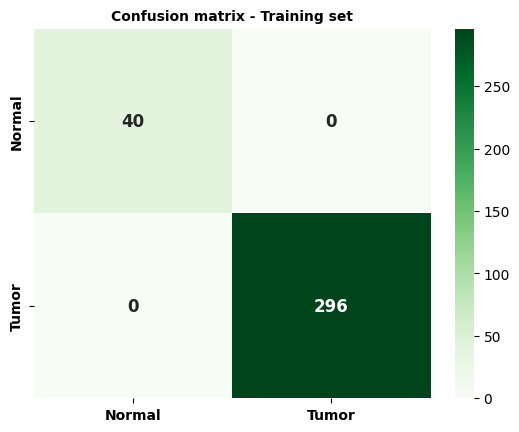

In [ ]:
ax= plt.subplot()
sns.heatmap(conf_matrix_train, annot=True, fmt='g', cmap='Greens', annot_kws={"weight": "bold", "size": 12},
            ax=ax)

ax.xaxis.set_ticklabels(['Normal', 'Tumor'], weight='bold')
ax.yaxis.set_ticklabels(['Normal', 'Tumor'], weight='bold')
plt.title('Confusion matrix - Training set', fontsize=10, weight='bold')
plt.savefig('confmatrix_train.png', facecolor='w', dpi=200, bbox_inches='tight')

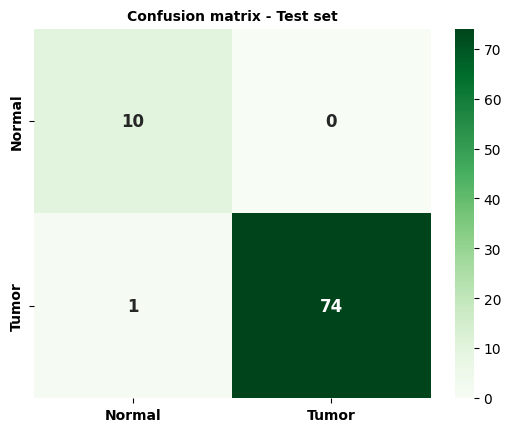

In [ ]:
ax= plt.subplot()
sns.heatmap(conf_matrix_test, annot=True, fmt='g', cmap='Greens', annot_kws={"weight": "bold", "size": 12},
            ax=ax)

ax.xaxis.set_ticklabels(['Normal', 'Tumor'], weight='bold')
ax.yaxis.set_ticklabels(['Normal', 'Tumor'], weight='bold')
plt.title('Confusion matrix - Test set', fontsize=10, weight='bold')
plt.savefig('confmatrix_test.png', facecolor='w', dpi=200, bbox_inches='tight')

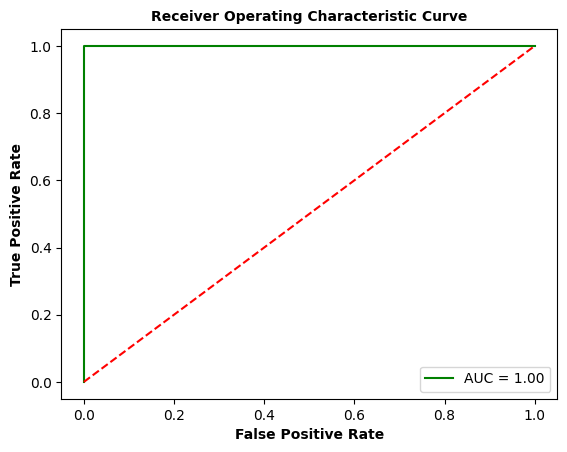

In [ ]:
probs = model.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic Curve', fontsize=10, weight='bold')
plt.plot(fpr, tpr, 'g', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.ylabel('True Positive Rate', weight='bold')
plt.xlabel('False Positive Rate', weight='bold')
plt.savefig('roc_auc.png', facecolor='w', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
filtered_expr[confirmed_features].transpose().to_csv('filtered_expr.csv', index=False)

In [ ]:
confirmed_features_detail.columns = ['ensembl_id', 'gene_name']